# 12-Mocking & Testing ML APIs

Over the last 11 lessons, we built a masterpiece. We engineered a secure, concurrent, decoupled API capable of streaming text, handling binary vision uploads, and orchestrating massive asynchronous background batches.

But as an Enterprise ML Engineer, your job is not done when the code works on your laptop. You must push this code to a GitHub repository, where a **CI/CD (Continuous Integration / Continuous Deployment)** pipeline will automatically run automated tests to ensure you didn't break anything.

Here lies the final, most expensive trap in AI Engineering: **If your automated tests actually run PyTorch, your company will go bankrupt.**

Let's set up our PyTorch and testing environment to master the physics of Mocking.

In [3]:
import torch
import torch.nn as nn
from fastapi import FastAPI, Depends
from fastapi.testclient import TestClient
from pydantic import BaseModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch, FastAPI, and PyTest Environment Ready.")

✅ PyTorch, FastAPI, and PyTest Environment Ready.


# 1. The Economics of the Testing Bottleneck

Imagine you have written **50 Unit Tests** to verify that your Pydantic schemas, security headers, and JSON responses work perfectly.

If your FastAPI route loads a 15GB Llama-3 model to run those tests:

1. **The Time Cost**: Loading the model takes 10 seconds. Running 50 tests sequentially will take $50 \times 10 = 500$ seconds (over 8 minutes) just to boot the model up and tear it down for every test environment.
2. **The Hardware Cost**: Standard GitHub Actions or GitLab CI runners use cheap CPUs. They do not have GPUs. To run a PyTorch test, you must rent specialized Cloud GPU Runners. At $3.00/hour, running tests on every single code commit across a team of 10 engineers will cost thousands of dollars a month.
3. **The Non-Determinism**: Neural networks are stochastic. If you test a generative LLM, it might output "The cat sat" on Tuesday, and "A feline rested" on Wednesday. You cannot write a strict `assert result == "The cat sat"` test because the math is fluid.

# 2. Dependency Injection (`Depends`)

To solve this, we must completely sever the PyTorch mathematics from the FastAPI routing logic during testing. We do this using **Dependency Injection**.

Instead of a route fetching a model from a global variable, we create a function whose sole job is to yield the model. We inject this function into the route using FastAPI's `Depends()` keyword.

```python
def get_neural_network():
    return RealMassivePyTorchModel()

@app.post("/predict")
async def predict(data: dict, model = Depends(get_neural_network)):
    return model(data)
```

# 3. The Mathematics of the Mock

Because we injected the model via `Depends()`, FastAPI gives us a superpower: `app.dependency_overrides`.

In our test file, we can tell FastAPI: *"Whenever a route asks for `get_neural_network`, intercept the request, and hand it this fake Python class instead."*

The fake class (The **Mock**) does not use PyTorch, it does not use a GPU, and it does not do any matrix multiplication. It simply returns a hardcoded, predetermined dictionary in $0.001$ seconds.

# 4. Architecting the Testable System

Let's build a clean FastAPI application using Dependency Injection, and then immediately write a PyTest script that completely bypasses the heavy mathematics.

### Part A: The Application Code (`main.py`)

In [4]:
# --- ⚙️ main.py ---
app = FastAPI(title="Testable AI API")

class PredictionRequest(BaseModel):
    text: str

class HeavyNeuralNetwork:
    def __init__(self):
        print("[SYSTEM] Loading 10GB Model into VRAM... (This costs $3.00/hr)")
        time.sleep(2.0) # Simulating heavy VRAM load
        
    def predict(self, text: str):
        # Simulated heavy matrix multiplication
        time.sleep(1.0)
        return {"prediction": "Positive", "confidence": 0.99}

# Initialize the heavy model ONCE (simulating lifespan or global state)
REAL_MODEL_INSTANCE = HeavyNeuralNetwork()

# The Dependency Function
def get_model():
    return REAL_MODEL_INSTANCE

# The Route
@app.post("/v1/analyze")
async def analyze_text(request: PredictionRequest, model: HeavyNeuralNetwork = Depends(get_model)):
    # The route has no idea if 'model' is real or fake!
    result = model.predict(request.text)
    return {"status": "success", "data": result}

[SYSTEM] Loading 10GB Model into VRAM... (This costs $3.00/hr)


### Part B: The Testing Code (`test_main.py`)

To test the API, we use Starlette's `TestClient`. It perfectly mimics an HTTP request, bypassing the actual network port and testing the Python routing directly.

In [5]:
# --- 🧪 test_main.py ---

# 1. Architect the Fake Machine
class MockNeuralNetwork:
    def __init__(self):
        print("[TEST] Initializing Mock Model... (Takes 0.0001 seconds, costs $0.00)")
        
    def predict(self, text: str):
        # We mathematically guarantee the exact same output every single time.
        # This allows us to write strict assert statements!
        return {"prediction": "MOCK_POSITIVE", "confidence": 1.0}

# 2. Execute the Override
def override_get_model():
    return MockNeuralNetwork()

# Tell FastAPI to swap the dependency
app.dependency_overrides[get_model] = override_get_model

# 3. Initialize the Test Client
client = TestClient(app)

print("\n--- 🚀 Executing Automated CI/CD Tests ---")

# Test 1: Testing Pydantic Validation
def test_empty_payload_rejected():
    response = client.post("/v1/analyze", json={}) # Missing 'text'
    assert response.status_code == 422 # FastAPI Unprocessable Entity
    print("✅ Test 1 Passed: Pydantic correctly blocked an empty payload.")

# Test 2: Testing the Logic via the Mock
def test_valid_payload_processed():
    response = client.post("/v1/analyze", json={"text": "I love this API!"})
    assert response.status_code == 200
    
    data = response.json()
    assert data["status"] == "success"
    # Because we mocked the model, we KNOW exactly what it will output.
    assert data["data"]["prediction"] == "MOCK_POSITIVE"
    assert data["data"]["confidence"] == 1.0
    print("✅ Test 2 Passed: API successfully routed the payload to the (mocked) model and returned JSON.")

# Run the tests
test_empty_payload_rejected()
test_valid_payload_processed()


--- 🚀 Executing Automated CI/CD Tests ---
[TEST] Initializing Mock Model... (Takes 0.0001 seconds, costs $0.00)
✅ Test 1 Passed: Pydantic correctly blocked an empty payload.
[TEST] Initializing Mock Model... (Takes 0.0001 seconds, costs $0.00)
✅ Test 2 Passed: API successfully routed the payload to the (mocked) model and returned JSON.


# 5. Visualizing the CI/CD Economics

To scientifically prove why Mocking is mandatory for AI Engineering, let's plot the cumulative time required to run a test suite of 100 API tests using the **Real GPU Model** versus the **Mocked Python Model**.

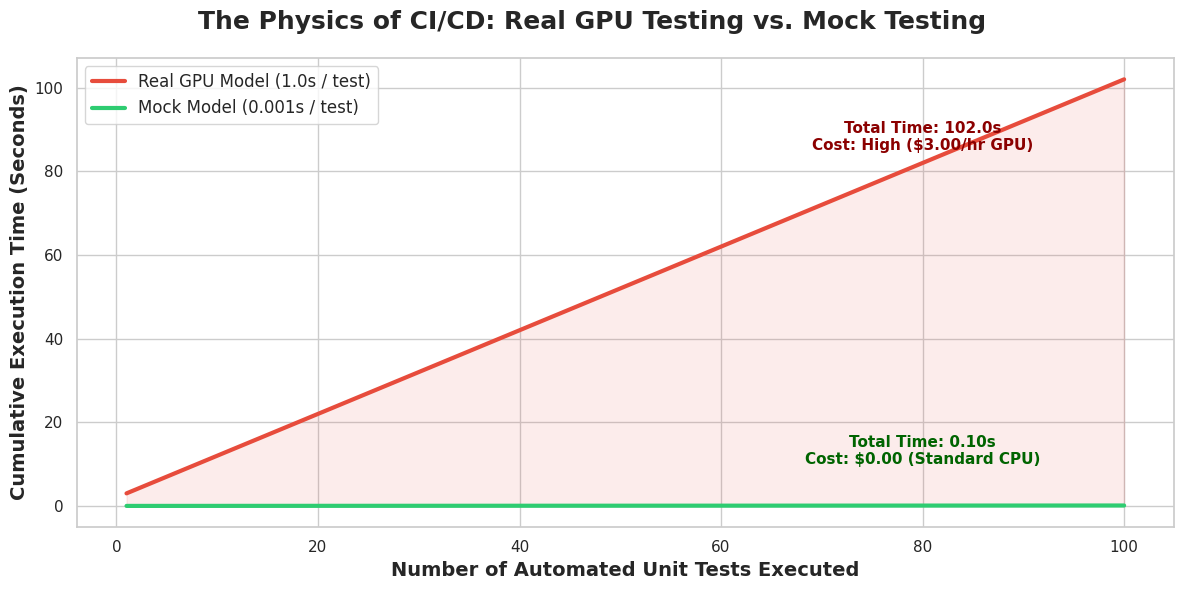


--- 💡 Engineering Insight ---
Look at the Red Line. Running just 100 unit tests on a real PyTorch model takes over a minute and a half. If a team of 10 engineers commits code 5 times a day, the CI/CD pipeline will be blocked for hours waiting for GPU compute, slowing down the entire company.
Look at the Green Line. By overriding the dependency, FastAPI routes the JSON exactly as it would in production, Pydantic validates the schemas perfectly, but the actual 'math' takes fractions of a millisecond. All 100 tests finish in 0.1 seconds, completely free of charge.


In [6]:
# 1. Define the Physics of the Tests
num_tests = 100

# Real GPU Physics: 2.0s load time + 1.0s inference per test
real_gpu_load_time = 2.0
real_gpu_inference_time = 1.0

# Mock Physics: 0.001s load time + 0.001s execution per test
mock_load_time = 0.001
mock_execution_time = 0.001

# Calculate cumulative time arrays
tests = np.arange(1, num_tests + 1)
cumulative_real_time = real_gpu_load_time + (tests * real_gpu_inference_time)
cumulative_mock_time = mock_load_time + (tests * mock_execution_time)

# 2. Render the Economic Visualization
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("The Physics of CI/CD: Real GPU Testing vs. Mock Testing", fontsize=18, fontweight='bold')

# Plot Real GPU
ax.plot(tests, cumulative_real_time, color='#e74c3c', linewidth=3, label="Real GPU Model (1.0s / test)")
ax.fill_between(tests, cumulative_real_time, color='#e74c3c', alpha=0.1)

# Plot Mock Model
ax.plot(tests, cumulative_mock_time, color='#2ecc71', linewidth=3, label="Mock Model (0.001s / test)")
ax.fill_between(tests, cumulative_mock_time, color='#2ecc71', alpha=0.3)

ax.set_xlabel("Number of Automated Unit Tests Executed", fontsize=14, fontweight='bold')
ax.set_ylabel("Cumulative Execution Time (Seconds)", fontsize=14, fontweight='bold')

# Annotations
ax.text(80, 85, f"Total Time: {cumulative_real_time[-1]:.1f}s\nCost: High ($3.00/hr GPU)", 
        fontsize=11, fontweight='bold', color='darkred', ha='center')

ax.text(80, 10, f"Total Time: {cumulative_mock_time[-1]:.2f}s\nCost: $0.00 (Standard CPU)", 
        fontsize=11, fontweight='bold', color='darkgreen', ha='center')

ax.legend(loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Red Line. Running just 100 unit tests on a real PyTorch model takes over a minute and a half. If a team of 10 engineers commits code 5 times a day, the CI/CD pipeline will be blocked for hours waiting for GPU compute, slowing down the entire company.")
print("Look at the Green Line. By overriding the dependency, FastAPI routes the JSON exactly as it would in production, Pydantic validates the schemas perfectly, but the actual 'math' takes fractions of a millisecond. All 100 tests finish in 0.1 seconds, completely free of charge.")

## Real-World Use Case or Analogy:

Think of Dependency Injection and Mocking like **Crash Testing a Car**:

* **Testing with the Real Model**: You want to test if the seatbelts and airbags work in a new car. To do this, you hire an actual human being, put them in the driver's seat, and crash the car into a wall at 60 MPH. Yes, you get highly accurate data, but the cost (human life/medical bills) is catastrophic, and you can only do it once.
* **Dependency Override (The Mock)**: You want to test the exact same seatbelts and airbags. Instead of a human, you use a **Crash Test Dummy** (The Mock Model). It weighs exactly the same, it fits in the seat perfectly, and the seatbelt mechanism (FastAPI routing/Pydantic) triggers exactly as it would in real life. But when the car crashes, the Dummy doesn't bleed. You can run 1,000 crash tests a day for pennies.